We will start up with the MC, then TD and finally TD(\lambda). Here we will still have the setting as before. Since MC needs policy to begin with, we will have a random policy to begin with. Remember that for MC control, we update Q(s,a)

Starting with MC, we

In [1]:
import numpy as np
#0 is wall, 1 is accessible
maze = np.array([
    [0,1,0,0,0,0,1,0],
    [0,1,0,1,1,0,1,1],
    [1,1,1,1,0,0,0,1],
    [0,0,1,0,0,1,1,1],
    [0,1,1,1,1,1,0,0],
    [0,1,0,0,0,1,1,0],
    [1,1,1,1,1,0,1,1],
    [0,1,0,0,1,1,1,0],
])

start = (0, 1)
goal = (6, 7)

In [2]:
actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1),
}

gamma = 1.0
step_reward = -1

In [3]:
def step(state, action):
    if state == goal:
        return goal, 0, True

    di, dj = actions[action]
    ni, nj = state[0] + di, state[1] + dj

    if (
        ni < 0 or ni >= maze.shape[0]
        or nj < 0 or nj >= maze.shape[1]
        or maze[ni, nj] == 0
    ):
        next_state = state
    else:
        next_state = (ni, nj)

    done = next_state == goal
    reward = 0 if done else step_reward
    return next_state, reward, done

Now we need one existing policy,

In [4]:
import random
import matplotlib.pyplot as plt

In [5]:
free_states = [
    (i, j)
    for i in range(maze.shape[0])
    for j in range(maze.shape[1])
    if maze[i, j] == 1
]

In [6]:
def legal_actions(state):
    valid = []

    for a in actions:
        ns, r, done = step(state, a)
        if ns != state or done:
            valid.append(a)

    return valid

In [7]:
def generate_episode(policy, start_state=start, max_steps=600):
    state = start_state
    episode = []

    for t in range(max_steps):
        action = policy(state)
        next_state, reward, done = step(state, action)

        episode.append((state, action, reward))

        state = next_state

        if done:
            break

    return episode

In [8]:
def random_policy(state):
    return random.choice(legal_actions(state))

In [9]:
def monte_carlo_prediction(policy, num_episodes=10000, alpha=0.05, gamma=1.0):
    V = np.zeros_like(maze, dtype=float)

    for ep in range(num_episodes):
        episode = generate_episode(policy)

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + gamma * G

            if state not in visited:
                V[state] += alpha * (G - V[state])
                visited.add(state)

    return V

In [10]:
from collections import defaultdict

In [11]:
def epsilon_greedy_action(Q, state, epsilon):
    valid = legal_actions(state)

    if random.random() < epsilon:
        return random.choice(valid)

    best_value = max(Q[state][a] for a in valid)
    best_actions = [a for a in valid if Q[state][a] == best_value]

    return random.choice(best_actions)

In [12]:
def mc_control(num_episodes=30000, gamma=1.0, epsilon=0.2, max_steps=600):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    counts = defaultdict(int)
    lengths = []

    for ep in range(num_episodes):
        policy = lambda state: epsilon_greedy_action(Q, state, epsilon)
        episode = generate_episode(policy, max_steps=max_steps)
        lengths.append(len(episode))

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + gamma * G

            if (state, action) not in visited:
                counts[(state, action)] += 1
                alpha = 1.0 / counts[(state, action)]

                Q[state][action] += alpha * (G - Q[state][action])
                visited.add((state, action))

    return Q, lengths

In [13]:
def greedy_policy_from_Q(Q):
    policy = {}

    for s in free_states:
        if s == goal:
            policy[s] = None
        else:
            valid = legal_actions(s)
            policy[s] = max(valid, key=lambda a: Q[s][a])

    return policy

In [14]:
def print_policy(policy):
    display = np.full(maze.shape, "#", dtype=object)

    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):

            if maze[i, j] == 0:
                display[i, j] = "#"
                continue

            s = (i, j)

            if s == goal:
                display[i, j] = "G"
            else:
                display[i, j] = arrow_map[policy[s]]

    for row in display:
        print(" ".join(row))

In [15]:
arrow_map = {
    "U": "↑",
    "D": "↓",
    "L": "←",
    "R": "→",
    None: "G"
}

In [16]:
Q_mc, lengths = mc_control()
mc_policy = greedy_policy_from_Q(Q_mc)

print_policy(mc_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # → ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [17]:
def sarsa_control(num_episodes=30000, alpha=0.1, gamma=1.0, epsilon=0.2, max_steps=600):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    lengths = []

    for ep in range(num_episodes):
        state = start
        action = epsilon_greedy_action(Q, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)

            steps += 1

            if done:
                target = reward
                Q[state][action] += alpha * (target - Q[state][action])
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon)

            target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (target - Q[state][action])

            state = next_state
            action = next_action

        lengths.append(steps)

    return Q, lengths

In [18]:
Q_sarsa, sarsa_lengths = sarsa_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    max_steps=600
)

sarsa_policy = greedy_policy_from_Q(Q_sarsa)

print_policy(sarsa_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ↓
→ → ↓ ← # # # ↑
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [19]:
episode = generate_episode(
    lambda s: sarsa_policy[s],
    start_state=start,
    max_steps=100
)

print("length:", len(episode))
print("return:", sum(r for _, _, r in episode))

for t, (s, a, r) in enumerate(episode):
    print(t, s, a)

length: 12
return: -11
0 (0, 1) D
1 (1, 1) D
2 (2, 1) R
3 (2, 2) D
4 (3, 2) D
5 (4, 2) R
6 (4, 3) R
7 (4, 4) R
8 (4, 5) D
9 (5, 5) R
10 (5, 6) D
11 (6, 6) R


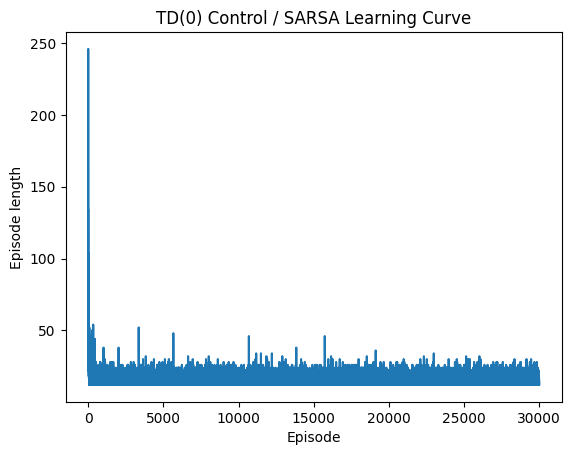

In [20]:
plt.plot(sarsa_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("TD(0) Control / SARSA Learning Curve")
plt.show()

In [21]:
def sarsa_lambda_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    lengths = []

    for ep in range(num_episodes):
        E = defaultdict(lambda: {a: 0.0 for a in actions})

        state = start
        action = epsilon_greedy_action(Q, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)
            steps += 1
            # Here goes the eligiblity trace
            if done:
                target = reward
                delta = target - Q[state][action]
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                target = reward + gamma * Q[next_state][next_action]
                delta = target - Q[state][action]

            E[state][action] += 1.0

            for s in list(E.keys()):
                for a in actions:
                    Q[s][a] += alpha * delta * E[s][a]
                    E[s][a] *= gamma * lam

            if done:
                break

            state = next_state
            action = next_action

        lengths.append(steps)

    return Q, lengths

In [22]:
Q_sarsa_lambda, sarsa_lambda_lengths = sarsa_lambda_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
)

sarsa_lambda_policy = greedy_policy_from_Q(Q_sarsa_lambda)

print_policy(sarsa_lambda_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↑ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [23]:
episode = generate_episode(
    lambda s: sarsa_lambda_policy[s],
    start_state=start,
    max_steps=100
)

print("length:", len(episode))
print("return:", sum(r for _, _, r in episode))

for t, (s, a, r) in enumerate(episode):
    print(t, s, a)

length: 12
return: -11
0 (0, 1) D
1 (1, 1) D
2 (2, 1) R
3 (2, 2) D
4 (3, 2) D
5 (4, 2) R
6 (4, 3) R
7 (4, 4) R
8 (4, 5) D
9 (5, 5) R
10 (5, 6) D
11 (6, 6) R


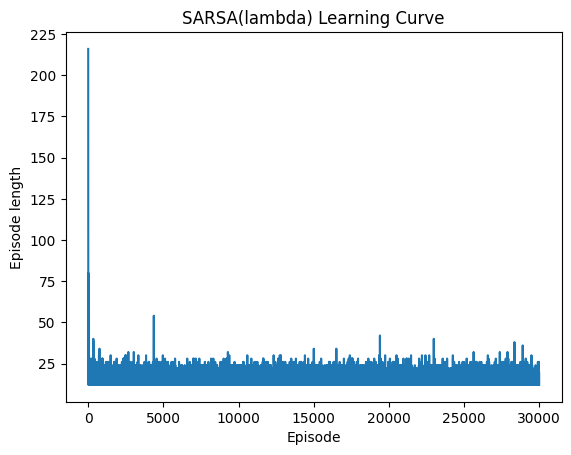

In [24]:
plt.plot(sarsa_lambda_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("SARSA(lambda) Learning Curve")
plt.show()

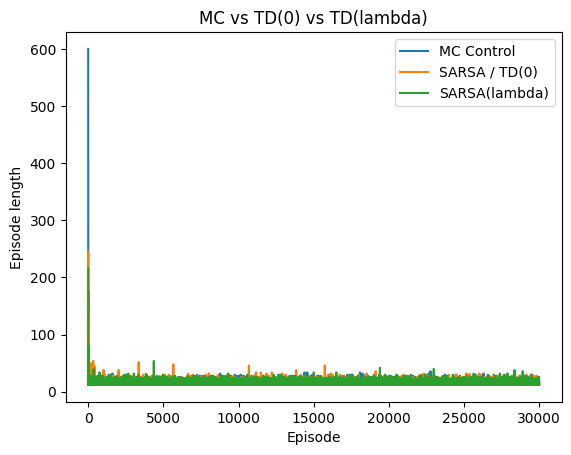

In [25]:
plt.plot(lengths, label="MC Control")
plt.plot(sarsa_lengths, label="SARSA / TD(0)")
plt.plot(sarsa_lambda_lengths, label="SARSA(lambda)")

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("MC vs TD(0) vs TD(lambda)")
plt.legend()
plt.show()

Here we will try parametric version of the sarsa.

In [26]:
state_to_idx = {s: i for i, s in enumerate(free_states)}
action_list = list(actions.keys())
action_to_idx = {a: i for i, a in enumerate(action_list)}

num_features = len(free_states) * len(action_list)

def featurize(state, action):
    x = np.zeros(num_features)

    s_idx = state_to_idx[state]
    a_idx = action_to_idx[action]

    idx = s_idx * len(action_list) + a_idx
    x[idx] = 1.0

    return x

In [27]:
def q_hat(w, state, action):
    x = featurize(state, action)
    return np.dot(w, x)

In [28]:
def epsilon_greedy_action_fa(w, state, epsilon):
    # access the legal actions
    valid = legal_actions(state)
    # if random number is smaller than epsilon, we pick arbitrary random legal actions
    if random.random() < epsilon:
        return random.choice(valid)
    # collect all the q values for legal actions
    q_values = [q_hat(w, state, a) for a in valid]
    max_q = max(q_values)
    best_actions = [a for a in valid if q_hat(w, state, a) == max_q]
    return random.choice(best_actions)

In [29]:
def sarsa_fa(
    num_episodes=30000,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.2,
    max_steps=600
):
    w = np.zeros(num_features)
    lengths = []

    for ep in range(num_episodes):
        state = start
        action = epsilon_greedy_action_fa(w, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)
            steps += 1

            x = featurize(state, action)

            if done:
                target = reward
            else:
                next_action = epsilon_greedy_action_fa(w, next_state, epsilon)
                target = reward + gamma * q_hat(w, next_state, next_action)

            delta = target - q_hat(w, state, action)

            w += alpha * delta * x

            if done:
                break

            state = next_state
            action = next_action

        lengths.append(steps)

    return w, lengths

In [30]:
w_sarsa_fa, sarsa_fa_lengths = sarsa_fa(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    max_steps=600
)

In [31]:
def greedy_policy_from_w(w):
    policy = {}

    for s in free_states:
        if s == goal:
            policy[s] = None
        else:
            valid = legal_actions(s)
            policy[s] = max(valid, key=lambda a: q_hat(w, s, a))

    return policy

In [32]:
def sarsa_lambda_fa(
    num_episodes=30000,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
):
    w = np.zeros(num_features)
    lengths = []

    for ep in range(num_episodes):
        e = np.zeros(num_features)

        state = start
        action = epsilon_greedy_action_fa(w, state, epsilon)

        steps = 0

        for t in range(max_steps):
            next_state, reward, done = step(state, action)
            steps += 1

            x = featurize(state, action)

            if done:
                target = reward
            else:
                next_action = epsilon_greedy_action_fa(w, next_state, epsilon)
                target = reward + gamma * q_hat(w, next_state, next_action)

            delta = target - q_hat(w, state, action)

            e = gamma * lam * e + x
            w += alpha * delta * e

            if done:
                break

            state = next_state
            action = next_action

        lengths.append(steps)

    return w, lengths

In [33]:
w_sarsa_lambda_fa, sarsa_lambda_fa_lengths = sarsa_lambda_fa(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    lam=0.8,
    max_steps=600
)

In [34]:
policy_sarsa_fa = greedy_policy_from_w(w_sarsa_fa)
policy_sarsa_lambda_fa = greedy_policy_from_w(w_sarsa_lambda_fa)

print_policy(policy_sarsa_fa)
print()
print_policy(policy_sarsa_lambda_fa)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #

# ↓ # # # # ↓ #
# ↓ # ↓ ← # → ←
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


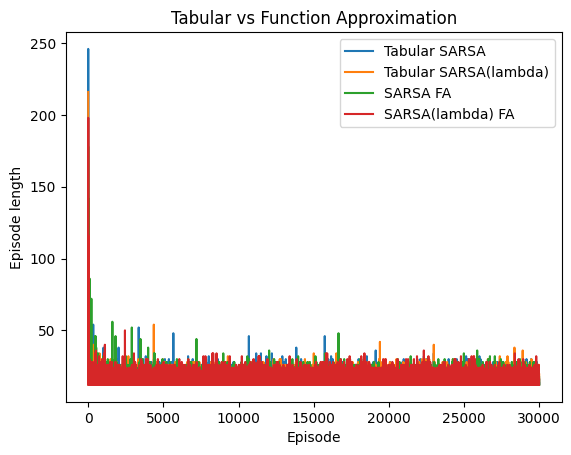

In [35]:
plt.plot(sarsa_lengths, label="Tabular SARSA")
plt.plot(sarsa_lambda_lengths, label="Tabular SARSA(lambda)")
plt.plot(sarsa_fa_lengths, label="SARSA FA")
plt.plot(sarsa_lambda_fa_lengths, label="SARSA(lambda) FA")

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("Tabular vs Function Approximation")
plt.legend()
plt.show()

In [36]:
def q_learning_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=1.0,
    epsilon=0.2,
    max_steps=600
):
    Q = defaultdict(lambda: {a: 0.0 for a in actions})
    lengths = []

    for ep in range(num_episodes):
        state = start
        steps = 0

        for t in range(max_steps):
            # behavior policy: epsilon-greedy
            action = epsilon_greedy_action(Q, state, epsilon)

            next_state, reward, done = step(state, action)
            steps += 1
            # Here we could also represent it using the method from book, which is to add indicator for terminal.
            if done:
                target = reward
            else:
                # target policy: greedy
                valid_next_actions = legal_actions(next_state)
                best_next_value = max(Q[next_state][a] for a in valid_next_actions)

                target = reward + gamma * best_next_value

            Q[state][action] += alpha * (target - Q[state][action])

            state = next_state

            if done:
                break

        lengths.append(steps)

    return Q, lengths

In [37]:
Q_qlearning, qlearning_lengths = q_learning_control(
    num_episodes=30000,
    alpha=0.1,
    gamma=gamma,
    epsilon=0.2,
    max_steps=600
)

qlearning_policy = greedy_policy_from_Q(Q_qlearning)

print_policy(qlearning_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ←
→ → ↓ ← # # # ↑
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↑ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


In [38]:
episode = generate_episode(
    lambda s: qlearning_policy[s],
    start_state=start,
    max_steps=100
)

print("length:", len(episode))
print("return:", sum(r for _, _, r in episode))

for t, (s, a, r) in enumerate(episode):
    print(t, s, a)

length: 12
return: -11
0 (0, 1) D
1 (1, 1) D
2 (2, 1) R
3 (2, 2) D
4 (3, 2) D
5 (4, 2) R
6 (4, 3) R
7 (4, 4) R
8 (4, 5) D
9 (5, 5) R
10 (5, 6) D
11 (6, 6) R


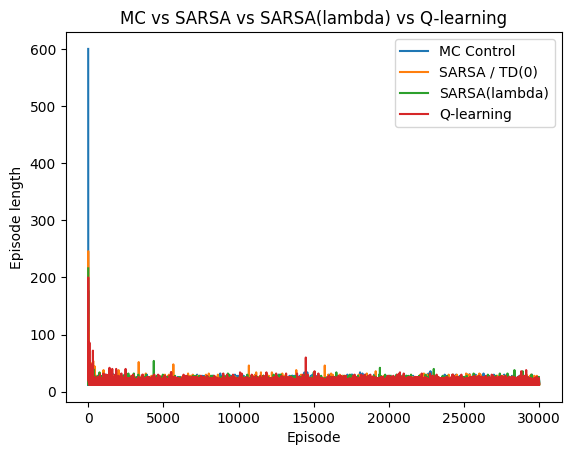

In [39]:
plt.plot(lengths, label="MC Control")
plt.plot(sarsa_lengths, label="SARSA / TD(0)")
plt.plot(sarsa_lambda_lengths, label="SARSA(lambda)")
plt.plot(qlearning_lengths, label="Q-learning")

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("MC vs SARSA vs SARSA(lambda) vs Q-learning")
plt.legend()
plt.show()

Now we will have a linear QN, starting with linear parametric ones. The parameter setting would be just $w_a$, stands for weights for action $a$, and we have feature $\phi$ for states. The value $Q(s,a)$ will be presented by $np.dot(w_a, \phi(s))$.

In [40]:
action_list = list(actions.keys())
action_to_idx = {a: i for i, a in enumerate(action_list)}
idx_to_action = {i: a for a, i in action_to_idx.items()}

The setting here assume that the order we made to the states are reasonable because it would output similar value for two states having similar position information. But what if we swap the order randomly? What if the order of states makes no sense?

In [41]:
def phi(state):
    i, j = state

    return np.array([
        1.0,                         # bias
        i / maze.shape[0],           # normalized row
        j / maze.shape[1],           # normalized col
        (i / maze.shape[0]) ** 2,
        (j / maze.shape[1]) ** 2,
        (i / maze.shape[0]) * (j / maze.shape[1])
    ])

In [42]:
num_features = len(phi(start))
num_actions = len(action_list)

def q_linear(W, state, action):
    a_idx = action_to_idx[action]
    return np.dot(W[a_idx], phi(state))

In [43]:
def epsilon_greedy_action_linear(W, state, epsilon):
    valid = legal_actions(state)

    if random.random() < epsilon:
        return random.choice(valid)

    return max(
        valid,
        key=lambda a: q_linear(W, state, a)
    )

In [44]:
from collections import deque
import random

def linear_q_learning_with_buffer(
    num_iterations=5000,
    env_steps_per_iter=20,
    gradient_steps=20,
    batch_size=32,
    buffer_size=5000,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2,
    max_episode_steps=200
):
    W = np.zeros((num_actions, num_features))
    replay_buffer = deque(maxlen=buffer_size)

    lengths = []
    weight_norms = []
    max_q_values = []
    td_errors = []

    state = start
    episode_steps = 0

    for k in range(num_iterations):

        # 1. collect experience
        for _ in range(env_steps_per_iter):
            action = epsilon_greedy_action_linear(W, state, epsilon)
            next_state, reward, done = step(state, action)

            replay_buffer.append((state, action, reward, next_state, done))

            episode_steps += 1
            state = next_state

            if done or episode_steps >= max_episode_steps:
                lengths.append(episode_steps)
                state = start
                episode_steps = 0

        # 2. gradient updates from replay buffer
        if len(replay_buffer) < batch_size:
            continue

        for _ in range(gradient_steps):
            batch = random.sample(replay_buffer, batch_size)

            grad = np.zeros_like(W)
            batch_td_errors = []

            for s, a, r, s_next, done in batch:
                a_idx = action_to_idx[a]

                current_q = q_linear(W, s, a)

                if done:
                    target = r
                else:
                    valid_next_actions = legal_actions(s_next)
                    best_next_q = max(
                        q_linear(W, s_next, a_next)
                        for a_next in valid_next_actions
                    )
                    target = r + gamma * best_next_q

                delta = target - current_q

                # semi-gradient:
                # W[a] += alpha * delta * phi(s)
                grad[a_idx] += delta * phi(s)

                batch_td_errors.append(abs(delta))

            W += alpha * grad / batch_size

            # optional safety
            W = np.clip(W, -1e3, 1e3)

            td_errors.append(np.mean(batch_td_errors))

        # diagnostics
        all_q = []
        for s in free_states:
            if s == goal:
                continue
            for a in legal_actions(s):
                all_q.append(q_linear(W, s, a))

        weight_norms.append(np.linalg.norm(W))
        max_q_values.append(np.max(np.abs(all_q)))

        if not np.isfinite(weight_norms[-1]) or not np.isfinite(max_q_values[-1]):
            print("Divergence detected at iteration:", k)
            break

    return W, lengths, weight_norms, max_q_values, td_errors

In [45]:
def greedy_policy_from_linear_Q(W):
    policy = {}

    for s in free_states:
        if s == goal:
            policy[s] = None
            continue

        valid = legal_actions(s)

        best_action = max(
            valid,
            key=lambda a: q_linear(W, s, a)
        )

        policy[s] = best_action

    return policy

In [46]:
W_buffer, buffer_lengths, buffer_weight_norms, buffer_max_q_values, buffer_td_errors = linear_q_learning_with_buffer(
    num_iterations=5000,
    env_steps_per_iter=20,
    gradient_steps=20,
    batch_size=32,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2
)

buffer_policy = greedy_policy_from_linear_Q(W_buffer)
print_policy(buffer_policy)

# ↓ # # # # ↓ #
# ↑ # → ← # → ←
→ ← ← ← # # # ↑
# # ↑ # # → → ↑
# ↓ ↑ → → ↓ # #
# ↓ # # # ↑ ↓ #
→ ↓ → → ↓ # ↓ G
# ↑ # # ↑ → ↑ #


As we see from here, the episode length always reach maximum, meaning that the model didn't perform better. We will take this chance to investigate the drawback and counter methods for parametric version. Starting with giving more information to the feature function $\phi$.

As we see from here, the episode length always reach maximum, meaning that the model didn't perform better. We will take this chance to investigate the drawback and counter methods for parametric version. Starting with giving more information to the feature function $\phi$. Here we will try adding more information to feature function. Starting with simply adding the blocking information.

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim

In [48]:
def encode_state(state):
    i, j = state
    H, W = maze.shape

    return torch.tensor(
        [i / H, j / W],
        dtype=torch.float32
    )

In [49]:
action_list = list(actions.keys())
action_to_idx = {a: i for i, a in enumerate(action_list)}
idx_to_action = {i: a for a, i in action_to_idx.items()}

In [50]:
class QNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, len(action_list))
        )

    def forward(self, x):
        return self.net(x)

In [51]:
def epsilon_greedy_action_qn(qnet, state, epsilon):
    valid = legal_actions(state)

    if random.random() < epsilon:
        return random.choice(valid)

    with torch.no_grad():
        q_values = qnet(encode_state(state))

    return max(
        valid,
        key=lambda a: q_values[action_to_idx[a]].item()
    )

In [52]:
def q_network_control(
    num_episodes=5000,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2,
    max_steps=200
):
    qnet = QNetwork()
    optimizer = optim.Adam(qnet.parameters(), lr=alpha)
    loss_fn = nn.MSELoss()

    lengths = []
    losses = []

    for ep in range(num_episodes):
        state = start
        steps = 0

        for t in range(max_steps):
            action = epsilon_greedy_action_qn(qnet, state, epsilon)
            next_state, reward, done = step(state, action)
            steps += 1

            q_values = qnet(encode_state(state))
            q_sa = q_values[action_to_idx[action]]

            with torch.no_grad():
                if done:
                    target = torch.tensor(float(reward))
                else:
                    next_q_values = qnet(encode_state(next_state))
                    best_next_q = max(
                        next_q_values[action_to_idx[a]].item()
                        for a in legal_actions(next_state)
                    )
                    target = torch.tensor(
                        reward + gamma * best_next_q,
                        dtype=torch.float32
                    )

            loss = loss_fn(q_sa, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            state = next_state

            if done:
                break

        lengths.append(steps)

    return qnet, lengths, losses

In [53]:
def greedy_policy_from_qnet(qnet):
    policy = {}

    for s in free_states:
        if s == goal:
            policy[s] = None
            continue

        with torch.no_grad():
            q_values = qnet(encode_state(s))

        policy[s] = max(
            legal_actions(s),
            key=lambda a: q_values[action_to_idx[a]].item()
        )

    return policy

In [54]:
qnet, qn_lengths, qn_losses = q_network_control(
    num_episodes=5000,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2,
    max_steps=200
)

qn_policy = greedy_policy_from_qnet(qnet)
print_policy(qn_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↓ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


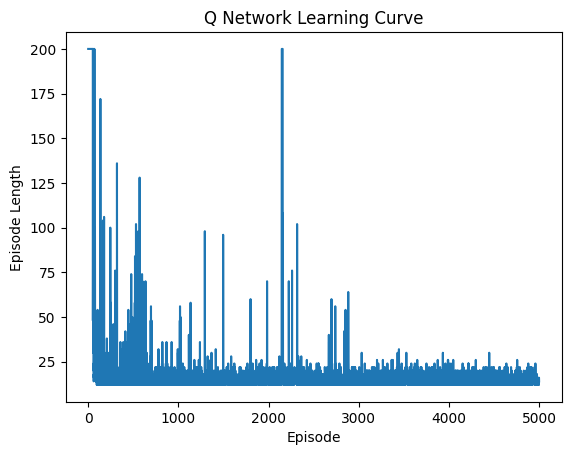

In [55]:
plt.plot(qn_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Q Network Learning Curve")
plt.show()

In [56]:
from collections import deque
import random
import torch
import torch.nn as nn
import torch.optim as optim

In [57]:
class QNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, len(action_list))
        )

    def forward(self, x):
        return self.net(x)

In [58]:
def dqn_control(
    num_episodes=5000,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2,
    max_steps=200,
    buffer_size=5000,
    batch_size=32,
    target_update_freq=100
):
    qnet = QNetwork()
    target_qnet = QNetwork()

    target_qnet.load_state_dict(qnet.state_dict())

    optimizer = optim.Adam(qnet.parameters(), lr=alpha)
    loss_fn = nn.MSELoss()

    replay_buffer = deque(maxlen=buffer_size)

    lengths = []
    losses = []
    total_steps = 0

    for ep in range(num_episodes):
        state = start
        steps = 0

        for t in range(max_steps):
            action = epsilon_greedy_action_qn(qnet, state, epsilon)
            next_state, reward, done = step(state, action)

            replay_buffer.append(
                (state, action, reward, next_state, done)
            )

            state = next_state
            steps += 1
            total_steps += 1

            if len(replay_buffer) >= batch_size:
                batch = random.sample(replay_buffer, batch_size)

                pred_qs = []
                targets = []

                for s, a, r, s_next, d in batch:
                    q_values = qnet(encode_state(s))
                    q_sa = q_values[action_to_idx[a]]
                    pred_qs.append(q_sa)

                    with torch.no_grad():
                        if d:
                            target = torch.tensor(
                                float(r),
                                dtype=torch.float32
                            )
                        else:
                            next_q_values = target_qnet(
                                encode_state(s_next)
                            )

                            best_next_q = max(
                                next_q_values[action_to_idx[a_next]].item()
                                for a_next in legal_actions(s_next)
                            )

                            target = torch.tensor(
                                r + gamma * best_next_q,
                                dtype=torch.float32
                            )

                    targets.append(target)

                pred_qs = torch.stack(pred_qs)
                targets = torch.stack(targets)

                loss = loss_fn(pred_qs, targets)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

            if total_steps % target_update_freq == 0:
                target_qnet.load_state_dict(qnet.state_dict())

            if done:
                break

        lengths.append(steps)

    return qnet, target_qnet, lengths, losses

In [60]:
dqn_qnet, dqn_target_qnet, dqn_lengths, dqn_losses = dqn_control(
    num_episodes=5000,
    alpha=0.001,
    gamma=0.99,
    epsilon=0.2,
    max_steps=200,
    buffer_size=5000,
    batch_size=32,
    target_update_freq=100
)

dqn_policy = greedy_policy_from_qnet(dqn_qnet)
print_policy(dqn_policy)

# ↓ # # # # ↓ #
# ↓ # ↓ ← # ↑ ↓
→ → ↓ ← # # # ↓
# # ↓ # # ↓ ← ←
# → → → → ↓ # #
# ↑ # # # → ↓ #
→ → → → ↓ # → G
# ↑ # # → → ↑ #


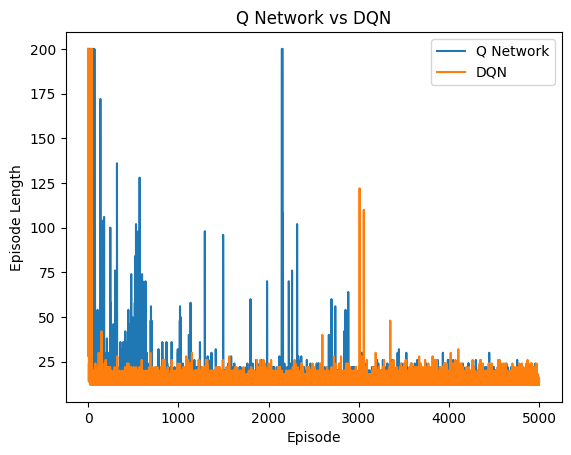

In [61]:
plt.plot(qn_lengths, label="Q Network")
plt.plot(dqn_lengths, label="DQN")

plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Q Network vs DQN")
plt.legend()
plt.show()